###### 129_3_light_quality_fill_review

In [2]:
#cell1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#cell2から実施のこと
df = pd.DataFrame(
    [
        ["D001", "J69P", "MELMB", "コイル", 1, np.nan, 300],
        ["D002", "J69P", "WSE", "Buck-IC", 2, 2, 280],
        ["D003", "310D", "GSE", "はんだ", 1, np.nan, 250],
        ["D004", "J69P", "MELMB", "コイル", 3, 4, 310],
        ["D005", "310D", "WSE", "NTF", 0, np.nan, 260],
        ["D006", "J69P", "GSE", "コイル", 2, np.nan, 290],
        ["D007", "310D", "MELMB", "はんだ", 1, 1, 240],
        ["D008", "J69P", "WSE", "Buck-IC", 1, np.nan, 270],
        ["D009", "J69P", "MELMB", "コイル", np.nan, np.nan, 320],
    ],
    columns=[
        "defect_id",
        "project",
        "site",
        "defect_category",
        "first_report_qty",
        "confirmed_qty",
        "inspection_qty",
    ],
)

df

,defect_id,project,site,defect_category,first_report_qty,confirmed_qty,inspection_qty
0,D001,J69P,MELMB,コイル,1.0,NaN,300
1,D002,J69P,WSE,Buck-IC,2.0,2.0,280
2,D003,310D,GSE,はんだ,1.0,NaN,250
3,D004,J69P,MELMB,コイル,3.0,4.0,310
4,D005,310D,WSE,NTF,0.0,NaN,260
5,D006,J69P,GSE,コイル,2.0,NaN,290
6,D007,310D,MELMB,はんだ,1.0,1.0,240
7,D008,J69P,WSE,Buck-IC,1.0,NaN,270
8,D009,J69P,MELMB,コイル,NaN,NaN,320


In [4]:
df_work = df.copy()
df_work

,defect_id,project,site,defect_category,first_report_qty,confirmed_qty,inspection_qty
0,D001,J69P,MELMB,コイル,1.0,NaN,300
1,D002,J69P,WSE,Buck-IC,2.0,2.0,280
2,D003,310D,GSE,はんだ,1.0,NaN,250
3,D004,J69P,MELMB,コイル,3.0,4.0,310
4,D005,310D,WSE,NTF,0.0,NaN,260
5,D006,J69P,GSE,コイル,2.0,NaN,290
6,D007,310D,MELMB,はんだ,1.0,1.0,240
7,D008,J69P,WSE,Buck-IC,1.0,NaN,270
8,D009,J69P,MELMB,コイル,NaN,NaN,320


In [5]:
df_work["defect_qty_for_analysis"] = df_work["confirmed_qty"].fillna(
    df_work["first_report_qty"]
)
df_work

,defect_id,project,site,defect_category,first_report_qty,confirmed_qty,inspection_qty,defect_qty_for_analysis
0,D001,J69P,MELMB,コイル,1.0,NaN,300,1.0
1,D002,J69P,WSE,Buck-IC,2.0,2.0,280,2.0
2,D003,310D,GSE,はんだ,1.0,NaN,250,1.0
3,D004,J69P,MELMB,コイル,3.0,4.0,310,4.0
4,D005,310D,WSE,NTF,0.0,NaN,260,0.0
5,D006,J69P,GSE,コイル,2.0,NaN,290,2.0
6,D007,310D,MELMB,はんだ,1.0,1.0,240,1.0
7,D008,J69P,WSE,Buck-IC,1.0,NaN,270,1.0
8,D009,J69P,MELMB,コイル,NaN,NaN,320,NaN


In [8]:
df_work["fill_method"] = "未確認"
df_work
df_work.loc[
    df_work["confirmed_qty"].notna(),
    "fill_method",
] = "規定値"
df_work
df_work.loc[
    df_work["confirmed_qty"].isna()
    & df_work["first_report_qty"].notna(),
    "fill_method",
] = "速報値で補完"
df_work

,defect_id,project,site,defect_category,first_report_qty,confirmed_qty,inspection_qty,defect_qty_for_analysis,fill_method
0,D001,J69P,MELMB,コイル,1.0,NaN,300,1.0,速報値で補完
1,D002,J69P,WSE,Buck-IC,2.0,2.0,280,2.0,規定値
2,D003,310D,GSE,はんだ,1.0,NaN,250,1.0,速報値で補完
3,D004,J69P,MELMB,コイル,3.0,4.0,310,4.0,規定値
4,D005,310D,WSE,NTF,0.0,NaN,260,0.0,速報値で補完
5,D006,J69P,GSE,コイル,2.0,NaN,290,2.0,速報値で補完
6,D007,310D,MELMB,はんだ,1.0,1.0,240,1.0,規定値
7,D008,J69P,WSE,Buck-IC,1.0,NaN,270,1.0,速報値で補完
8,D009,J69P,MELMB,コイル,NaN,NaN,320,NaN,未確認


In [9]:
df_check_fill = df_work[
    [
        "defect_id",
        "project",
        "site",
        "defect_category",
        "first_report_qty",
        "confirmed_qty",
        "defect_qty_for_analysis",
        "fill_method",
    ]
].copy()

df_check_fill

,defect_id,project,site,defect_category,first_report_qty,confirmed_qty,defect_qty_for_analysis,fill_method
0,D001,J69P,MELMB,コイル,1.0,NaN,1.0,速報値で補完
1,D002,J69P,WSE,Buck-IC,2.0,2.0,2.0,規定値
2,D003,310D,GSE,はんだ,1.0,NaN,1.0,速報値で補完
3,D004,J69P,MELMB,コイル,3.0,4.0,4.0,規定値
4,D005,310D,WSE,NTF,0.0,NaN,0.0,速報値で補完
5,D006,J69P,GSE,コイル,2.0,NaN,2.0,速報値で補完
6,D007,310D,MELMB,はんだ,1.0,1.0,1.0,規定値
7,D008,J69P,WSE,Buck-IC,1.0,NaN,1.0,速報値で補完
8,D009,J69P,MELMB,コイル,NaN,NaN,NaN,未確認


In [10]:
df_unconfirmed = df_work[
    df_work["fill_method"] == "未確認"
].copy()

df_unconfirmed

,defect_id,project,site,defect_category,first_report_qty,confirmed_qty,inspection_qty,defect_qty_for_analysis,fill_method
8,D009,J69P,MELMB,コイル,NaN,NaN,320,NaN,未確認


In [11]:
df_analysis = df_work[
    df_work["fill_method"] != "未確認"
].copy()
df_analysis

,defect_id,project,site,defect_category,first_report_qty,confirmed_qty,inspection_qty,defect_qty_for_analysis,fill_method
0,D001,J69P,MELMB,コイル,1.0,NaN,300,1.0,速報値で補完
1,D002,J69P,WSE,Buck-IC,2.0,2.0,280,2.0,規定値
2,D003,310D,GSE,はんだ,1.0,NaN,250,1.0,速報値で補完
3,D004,J69P,MELMB,コイル,3.0,4.0,310,4.0,規定値
4,D005,310D,WSE,NTF,0.0,NaN,260,0.0,速報値で補完
5,D006,J69P,GSE,コイル,2.0,NaN,290,2.0,速報値で補完
6,D007,310D,MELMB,はんだ,1.0,1.0,240,1.0,規定値
7,D008,J69P,WSE,Buck-IC,1.0,NaN,270,1.0,速報値で補完


In [13]:
df_site_total = df_analysis.pivot_table(
    values="defect_qty_for_analysis",
    index="site",
    aggfunc="sum",
)

df_site_total

,defect_qty_for_analysis
site,
GSE,3.0
MELMB,6.0
WSE,3.0


In [14]:
df_site_total_sort = df_site_total.sort_values(
    "defect_qty_for_analysis",
    ascending=False,
)

df_site_total_sort

,defect_qty_for_analysis
site,
MELMB,6.0
GSE,3.0
WSE,3.0


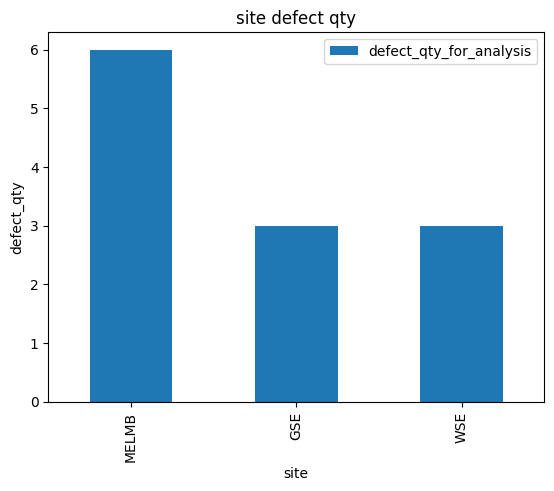

In [15]:
df_site_total_sort.plot(
    kind="bar",
    y="defect_qty_for_analysis",
)

plt.title("site defect qty")
plt.xlabel("site")
plt.ylabel("defect_qty")
plt.show()